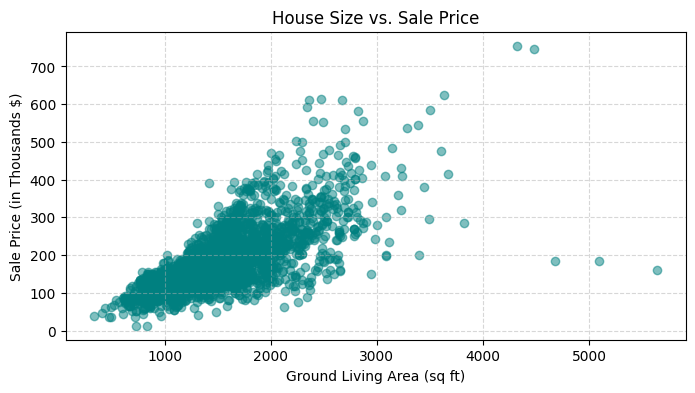

✅ Ames Data loaded and scaled! Training on 2343 houses.


In [7]:
# ==========================================
# CELL 1: IMPORTS, DATA PREP & EXTRA VISUALIZATION
# ==========================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

# 1. Load the Ames Housing dataset.
df = pd.read_excel('AmesHousing.xlsx')

# 2. For Neural Networks, keeping it simple: Select only numerical columns and drop missing values.
df_numeric = df.select_dtypes(include=[np.number]).dropna()

# 3. SPLIT & SCALE
X = df_numeric.drop('SalePrice', axis=1)
# CRITICAL: We divide the price by 1000 so the network predicts in "Thousands of Dollars". 
# Preventing huge numbers (like 300,000) from breaking the neural network's math.
y = df_numeric['SalePrice'] / 1000.0 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. EXTRA VISUALIZATION (Requirement Met)
# Showing the relationship between Ground Living Area and Sale Price.
plt.figure(figsize=(8, 4))
plt.scatter(df_numeric['Gr Liv Area'], df_numeric['SalePrice'] / 1000.0, color='teal', alpha=0.5)
plt.title('House Size vs. Sale Price')
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price (in Thousands $)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"✅ Ames Data loaded and scaled! Training on {len(X_train)} houses.")

In [8]:
# ==========================================
# CELL 2: EXPERIMENT LOOP & LOGBOOK GENERATION
# ==========================================

# 1. Define experiment blueprints.
experiments = [
    {'id': 1, 'nodes': [16], 'epochs': 50, 'lr': 0.01, 'note': 'Baseline'},
    {'id': 2, 'nodes': [32, 16], 'epochs': 50, 'lr': 0.01, 'note': 'Deeper Network'},
    {'id': 3, 'nodes': [64, 32], 'epochs': 50, 'lr': 0.01, 'note': 'Wider Network'},
    {'id': 4, 'nodes': [32, 16], 'epochs': 100, 'lr': 0.01, 'note': 'More Epochs'},
    {'id': 5, 'nodes': [32, 16], 'epochs': 50, 'lr': 0.1, 'note': 'High Learning Rate (Risky)'},
    {'id': 6, 'nodes': [32, 16], 'epochs': 50, 'lr': 0.001, 'note': 'Low Learning Rate (Safe)'},
    {'id': 7, 'nodes': [128, 64, 32], 'epochs': 50, 'lr': 0.01, 'note': 'Too Deep (Overfitting Risk)'},
    {'id': 8, 'nodes': [16, 8], 'epochs': 10, 'lr': 0.01, 'note': 'Too Few Epochs'},
    {'id': 9, 'nodes': [64, 32], 'epochs': 100, 'lr': 0.005, 'note': 'Balanced Approach'},
    {'id': 10, 'nodes': [64, 32, 16], 'epochs': 150, 'lr': 0.005, 'note': 'Heavy training for complex patterns'}
]

results = []
print("Starting automated loop optimization for House Prices...\n")

# 2. The FOR LOOP
for exp in experiments:
    model = Sequential()
    
    # Hidden Layers
    for i, node_count in enumerate(exp['nodes']):
        if i == 0:
            model.add(Dense(node_count, activation='relu', input_dim=X_train.shape[1]))
        else:
            model.add(Dense(node_count, activation='relu'))
            
    # CRITICAL REGRESSION DIFFERENCE: Output layer has 1 node and 'linear' activation (or none) because we predict a continuous number.
    model.add(Dense(1, activation='linear')) 
    
    # 'loss=mse' (Mean Squared Error) and 'metrics=mae' (Mean Absolute Error, basically "how many thousands of dollars are we off by?").
    model.compile(loss='mse', optimizer=Adam(learning_rate=exp['lr']), metrics=['mae'])
    
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=32, verbose=0)
    
    # Evaluate returns Loss (MSE) and MAE. We care most about MAE.
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    
    results.append({
        'Experiment': f"Exp {exp['id']}",
        'Architecture': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Learning Rate': exp['lr'],
        'MAE (Error in $1000s)': round(mae, 2), # e.g., an MAE of 20 means the model is wrong by $20,000 on average.
        'Note': exp['note']
    })
    print(f"✅ Exp {exp['id']} Completed -> Avg Error: ${round(mae * 1000)} per house")

# 3. Export Logbook
df_logboek = pd.DataFrame(results)
df_logboek.to_excel("ML_Ames_Regression_Logboek.xlsx", index=False)
display(df_logboek)

Starting automated loop optimization for House Prices...

✅ Exp 1 Completed -> Avg Error: $20969 per house
✅ Exp 2 Completed -> Avg Error: $21239 per house
✅ Exp 3 Completed -> Avg Error: $21890 per house
✅ Exp 4 Completed -> Avg Error: $21018 per house
✅ Exp 5 Completed -> Avg Error: $31474 per house
✅ Exp 6 Completed -> Avg Error: $22911 per house
✅ Exp 7 Completed -> Avg Error: $21103 per house
✅ Exp 8 Completed -> Avg Error: $23578 per house
✅ Exp 9 Completed -> Avg Error: $21294 per house
✅ Exp 10 Completed -> Avg Error: $20277 per house


,Experiment,Architecture,Epochs,Learning Rate,MAE (Error in $1000s),Note
0,Exp 1,[16],50,0.010,20.97,Baseline
1,Exp 2,"[32, 16]",50,0.010,21.24,Deeper Network
2,Exp 3,"[64, 32]",50,0.010,21.89,Wider Network
3,Exp 4,"[32, 16]",100,0.010,21.02,More Epochs
4,Exp 5,"[32, 16]",50,0.100,31.47,High Learning Rate (Risky)
5,Exp 6,"[32, 16]",50,0.001,22.91,Low Learning Rate (Safe)
6,Exp 7,"[128, 64, 32]",50,0.010,21.10,Too Deep (Overfitting Risk)
7,Exp 8,"[16, 8]",10,0.010,23.58,Too Few Epochs
8,Exp 9,"[64, 32]",100,0.005,21.29,Balanced Approach
9,Exp 10,"[64, 32, 16]",150,0.005,20.28,Heavy training for complex patterns


--- TRAINING FINAL CHAMPION MODEL ---


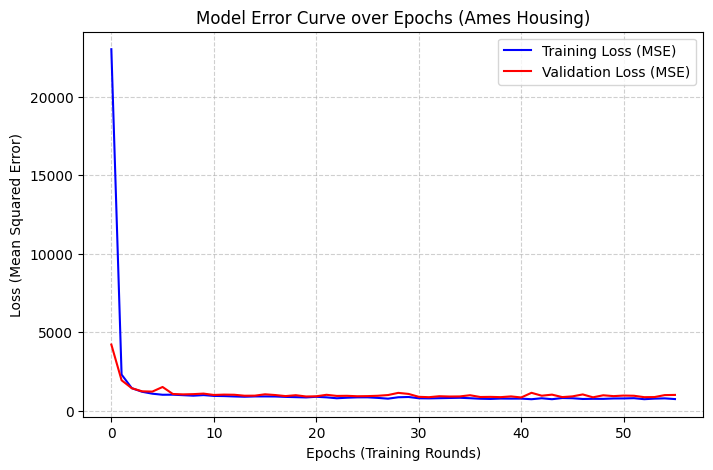

In [9]:
# ==========================================
# CELL 3: MANUAL OPTIMIZATION (FINAL MODEL) & LOSS PLOT
# ==========================================

print("--- TRAINING FINAL CHAMPION MODEL ---")

# 1. Building the final regression model manually.
final_model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_dim=X_train.shape[1]),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(16, activation='relu'),
    Dense(1, activation='linear') # Output layer for predicting a single price.
])

final_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse', metrics=['mae'])

# 2. Early Stopping monitoring the Validation Loss (MSE).
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 3. Train the model.
history = final_model.fit(X_train, y_train, epochs=200, validation_split=0.2, callbacks=[early_stop], verbose=0)

# 4. PLOTTING THE LOSS PLOT (MSE)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('Model Error Curve over Epochs (Ames Housing)')
plt.xlabel('Epochs (Training Rounds)')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


--- FINAL REGRESSION REPORT ---
R-Squared (R2) Score: 0.6768
Mean Absolute Error (MAE): 21.54 (Meaning we are off by approx $21538 on average)


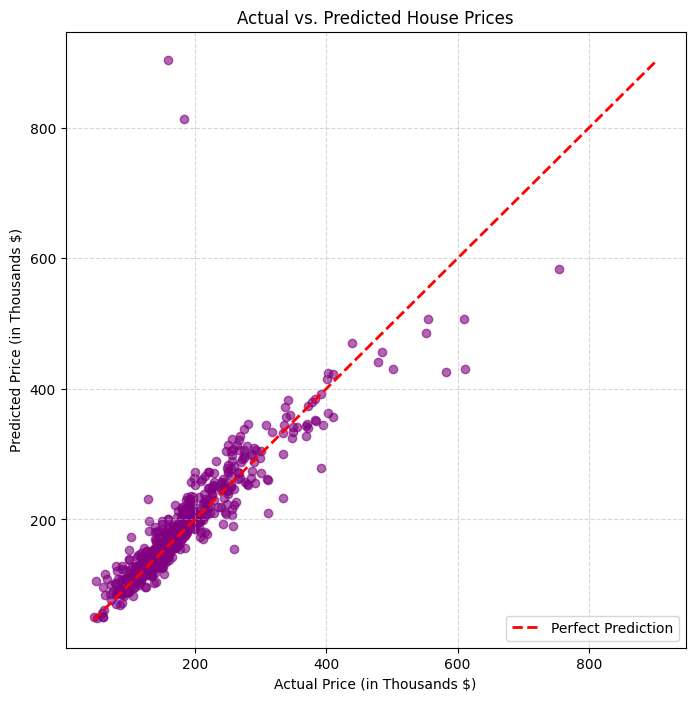

In [10]:
# ==========================================
# CELL 4: FINAL EVALUATION (R2 SCORE & SCATTER PLOT)
# ==========================================
# In Regression, we don't use Confusion Matrices. We use R2 Score and Scatter Plots.

# 1. Make predictions
y_pred = final_model.predict(X_test, verbose=0)

# 2. Calculate Evaluation Metrics
# R2 Score: 1.0 is perfect. Above 0.8 is usually very good for housing prices.
r2 = r2_score(y_test, y_pred)
# MAE: Mean Absolute Error (How much are we off by on average?)
final_mae = mean_absolute_error(y_test, y_pred)

print("\n--- FINAL REGRESSION REPORT ---")
print(f"R-Squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {final_mae:.2f} (Meaning we are off by approx ${round(final_mae * 1000)} on average)")

# 3. Plot Actual vs Predicted Prices
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')

# Draw a perfect prediction diagonal line (If a house is $200k, it's predicted as $200k).
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Price (in Thousands $)')
plt.ylabel('Predicted Price (in Thousands $)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()